Shape: (4521, 17)
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  

✅ Accuracy: 89.72%

Classification Report:
              precision    recall  f1-score   sup

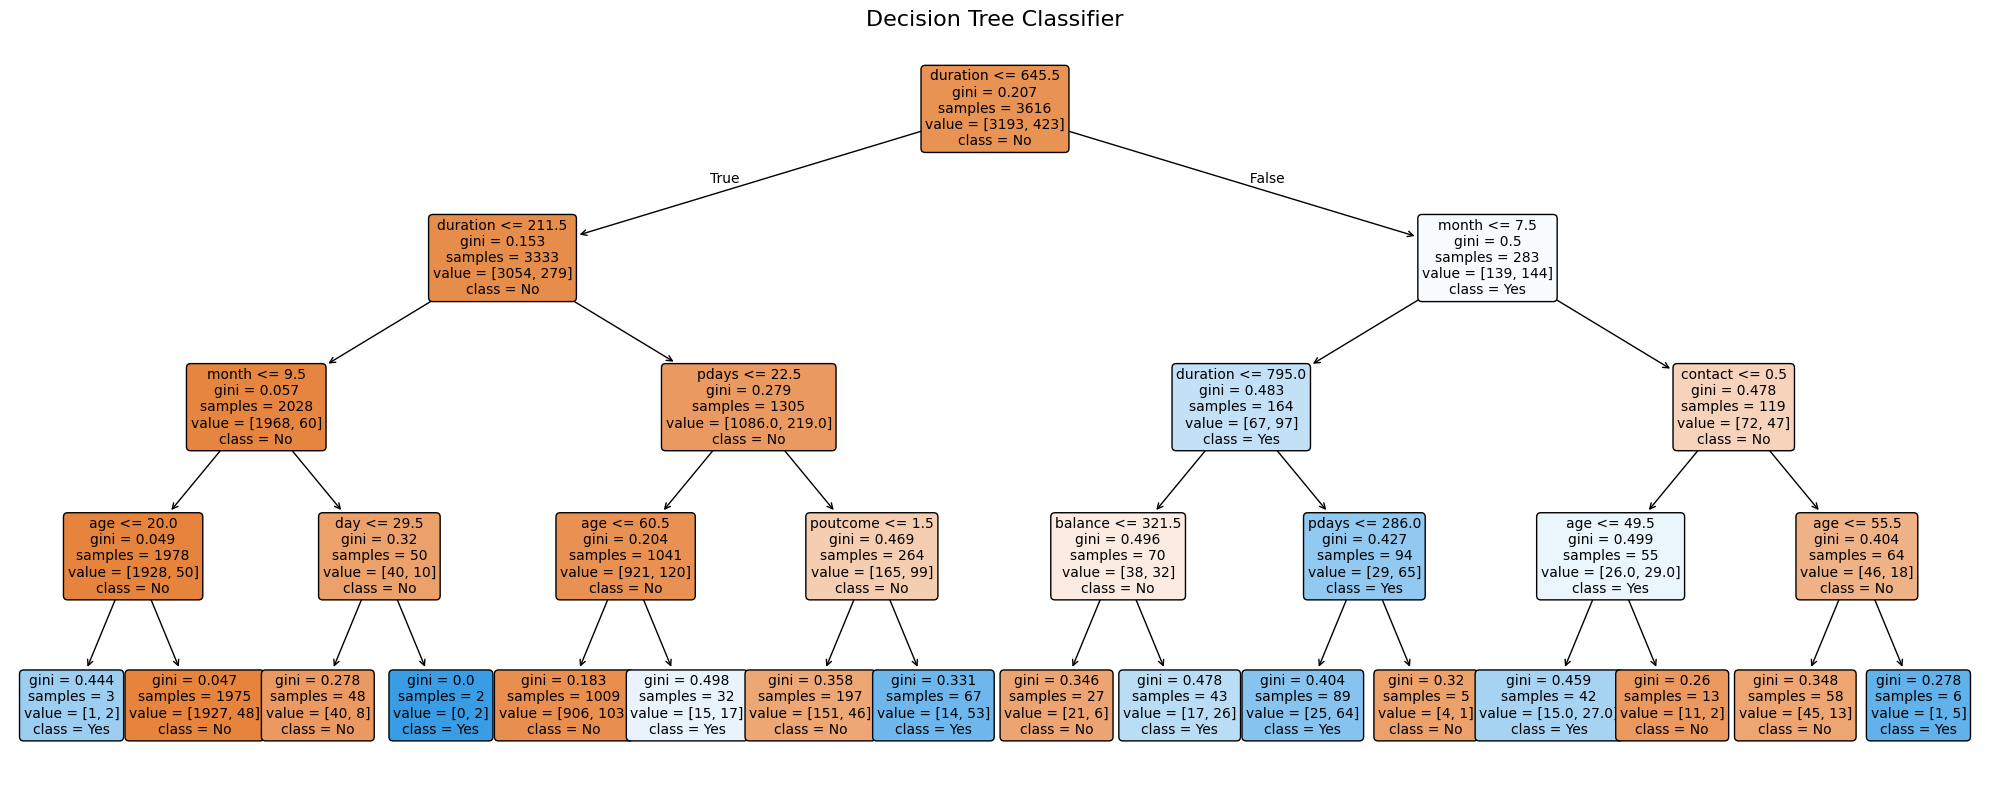

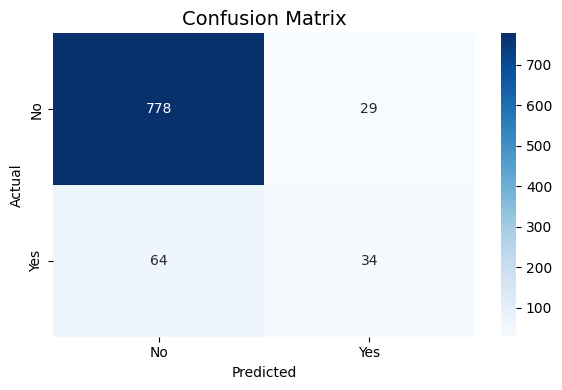

/tmp/ipykernel_5915/1954583189.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')


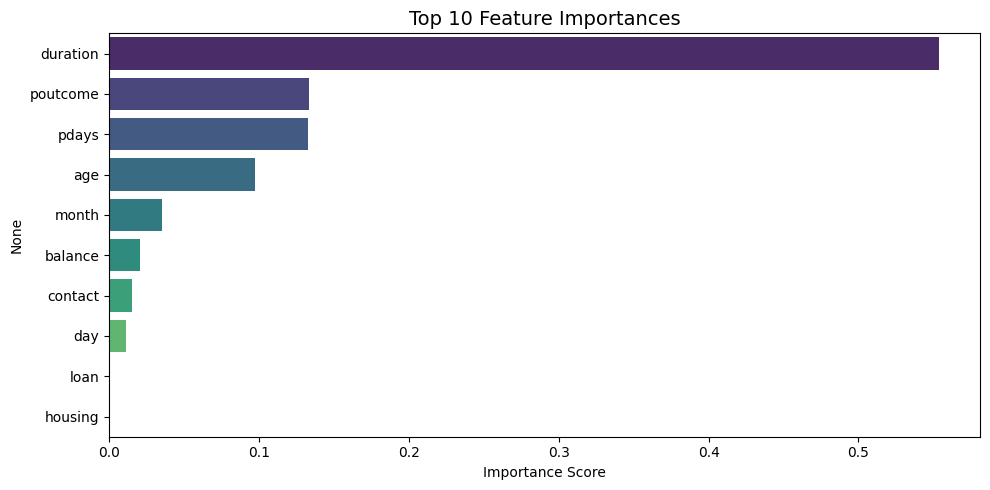

✅ All Task 03 charts saved!


In [1]:
# ============================================================
# PRODIGY INFOTECH - DATA SCIENCE INTERNSHIP
# Task 03: Decision Tree Classifier
# Dataset: Bank Marketing Dataset
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# ── Load Dataset ──────────────────────────────────────────
df = pd.read_csv('bank.csv', sep=';')  # change filename if different
print("Shape:", df.shape)
print(df.head())

# ── Data Preprocessing ────────────────────────────────────
# Encode categorical columns
le = LabelEncoder()
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Features and Target
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ── Build Decision Tree ───────────────────────────────────
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# ── Accuracy ──────────────────────────────────────────────
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ── Chart 1: Decision Tree Visualization ──────────────────
plt.figure(figsize=(20, 8))
plot_tree(clf, feature_names=X.columns.tolist(),
          class_names=['No', 'Yes'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Classifier', fontsize=16)
plt.tight_layout()
plt.savefig('Task03_decision_tree.png', dpi=150)
plt.show()

# ── Chart 2: Confusion Matrix ─────────────────────────────
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('Task03_confusion_matrix.png', dpi=150)
plt.show()

# ── Chart 3: Feature Importance ───────────────────────────
feat_importance = pd.Series(clf.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')
plt.title('Top 10 Feature Importances', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('Task03_feature_importance.png', dpi=150)
plt.show()

print("✅ All Task 03 charts saved!")